In [2]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

print("Environment is ready")

Environment is ready


In [4]:
data=pd.read_csv("Cleaned_Dataset.csv")
data

,Company,Company Score,Job Title,Date,Salary,Skills,Estimation Type,Remote,City,Country
0,Razorpoint,3.4,Junior Data Scientist,3.0,35000.0,"Data mining, Big data, R, Data analysis skills...",Employer est.,Onsite,Manchester,England
1,tower Hamlets,3.7,Assistant Data Scientist (Graduate) | R-2375,5.0,64480.0,"R, SQL, JavaScript, Python",Employer est.,Onsite,London,England
2,TW,4.0,Data Scientist,31.0,57500.0,"SQL, Maths, Data science, Python",Employer est.,Onsite,Nottingham,England
3,NatWest Group,4.6,Data Scientist,2.0,47500.0,"Software deployment, Data analysis skills, Sta...",Glasdoor est.,Onsite,Edinburgh,Scotland
4,iwoca,3.9,Data Scientist - Ops,7.0,75000.0,"MATLAB, R, Maths, C, Machine learning",Employer est.,Onsite,London,England
...,...,...,...,...,...,...,...,...,...,...
630,Qureight Ltd,3.4,Senior Machine Learning Scientist/Engineer,13.0,52500.0,"Oracle, Cloud architecture, CSS, DevOps, PaaS",Glasdoor est.,Onsite,London,England
631,Causaly,3.5,Machine Learning Engineer,35.0,90000.0,"Data science, Account management, Communicatio...",Glasdoor est.,Onsite,London,England
632,GSK,3.8,Senior AI/ML Engineer - Computer Vision,30.0,41000.0,"TensorFlow, Cloud infrastructure, Software dep...",Glasdoor est.,Onsite,London,England
633,InstaDeep,3.7,"Applied Research Scientist, Explainable Deep L...",35.0,49920.0,"TensorFlow, Software deployment, NoSQL, Englis...",Employer est.,Onsite,London,England


In [5]:
data.shape

(635, 10)

In [7]:
data.columns

Index(['Company', 'Company Score', 'Job Title', 'Date', 'Salary', 'Skills',
       'Estimation Type', 'Remote', 'City', 'Country'],
      dtype='object')

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 635 entries, 0 to 634
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Company          635 non-null    object 
 1   Company Score    635 non-null    float64
 2   Job Title        635 non-null    object 
 3   Date             635 non-null    float64
 4   Salary           635 non-null    float64
 5   Skills           635 non-null    object 
 6   Estimation Type  635 non-null    object 
 7   Remote           635 non-null    object 
 8   City             581 non-null    object 
 9   Country          581 non-null    object 
dtypes: float64(3), object(7)
memory usage: 49.7+ KB


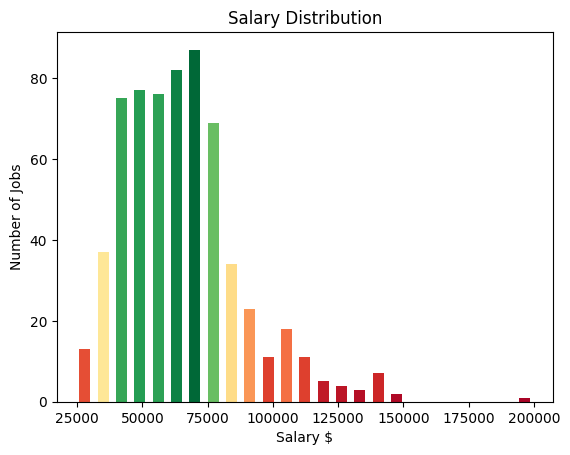

In [18]:
plt.figure()
counts,bins,patches=plt.hist(data['Salary'], bins=25,rwidth=0.6)

norm=plt.Normalize(counts.min(), counts.max()) #normalize values for colour mapping
for count,patch in zip(counts,patches):
    color=plt.cm.RdYlGn(norm(count)) # Red--> yellow-->greenb
    patch.set_facecolor(color)
    
plt.title("Salary Distribution")
plt.xlabel("Salary $")
plt.ylabel("Number of Jobs")
plt.show()

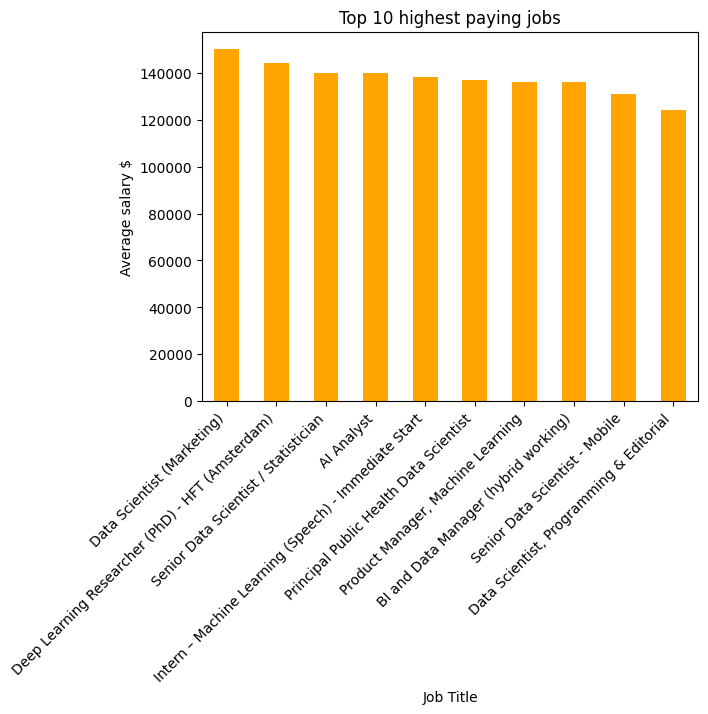

In [23]:
top_jobs= data.groupby('Job Title')['Salary'].mean().sort_values(ascending=False).head(10)
plt.figure()
top_jobs.plot(kind='bar', color='orange')
plt.title("Top 10 highest paying jobs")
plt.xlabel("Job Title")
plt.ylabel("Average salary $")
plt.xticks(rotation=45, ha='right')
plt.show()

# This chart answers: Which Data jobs pay the most on average? 


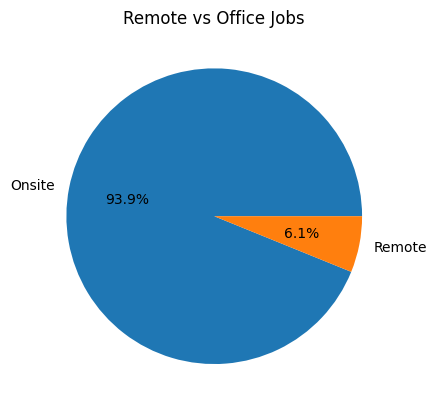

In [24]:
remote_count = data['Remote'].value_counts() # This line counts how many jobs falls into each category in the remote column
plt.figure()
plt.pie(remote_count,labels=remote_count.index, autopct='%1.1f%%')
plt.title("Remote vs Office Jobs")
plt.show()


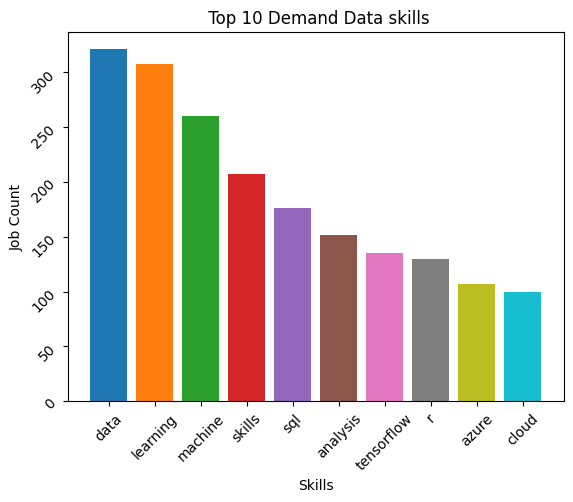

In [33]:
from collections import Counter
all_skills = ' '.join(data['Skills'].dropna()).lower()
#' '.join(...) combines all the skills from all rows into one long string.lower() converts all the strings to lowercase to avoid counting the same skill twice

skill=all_skills.replace(',','').split()
top_skills = Counter(skill).most_common(10)
#counter: counts how many times each skill appears in the list, most_common: return a list of 10 most frequent skills

skills_df = pd.DataFrame(top_skills, columns=['skill','count']
                        )
plt.figure()
colors= plt.cm.tab10.colors # generate a color for each bar. 10 distinct colors
plt.bar(skills_df['skill'],skills_df['count'], color=colors)
plt.title(" Top 10 Demand Data skills")
plt.xlabel("Skills")
plt.ylabel("Job Count")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()


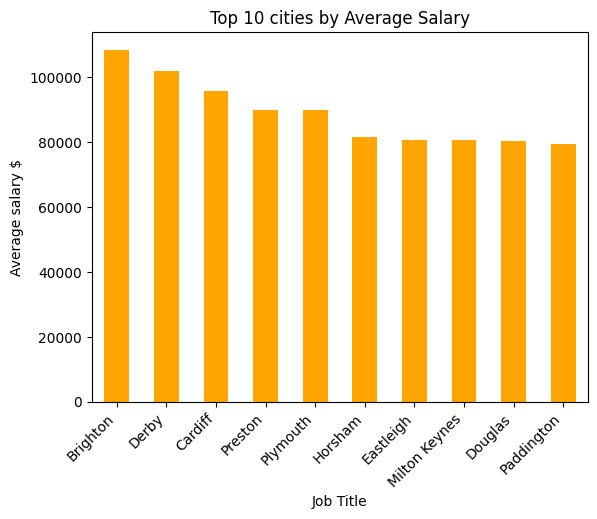

In [31]:
top_jobs= data.groupby('City')['Salary'].mean().sort_values(ascending=False).head(10)
plt.figure()
top_jobs.plot(kind='bar', color='orange')
plt.title("Top 10 cities by Average Salary")
plt.xlabel("Job Title")
plt.ylabel("Average salary $")
plt.xticks(rotation=45, ha='right')
plt.show()

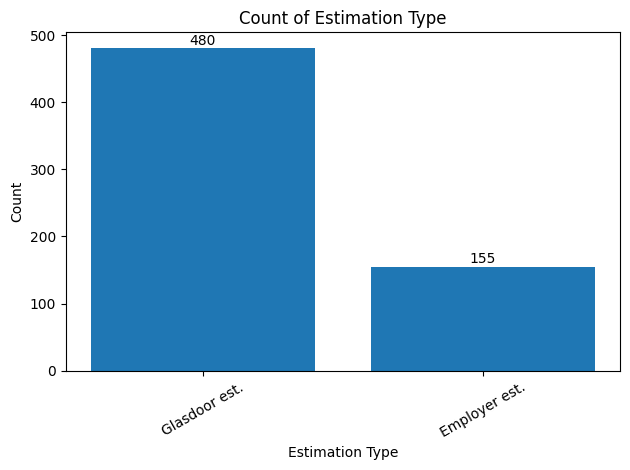

In [48]:
Estimation_count = data['Estimation Type'].value_counts()
plt.figure()
bars = plt.bar(Estimation_count.index,Estimation_count.values)
for bar in bars:
    yval=bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval+1, int(yval),ha='center',va='bottom',fontsize=10)

plt.title("Count of Estimation Type")
plt.xlabel("Estimation Type")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()